# **Cab Price Prediction**

Import library

In [3]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

Upload data files (only needed once per Colab session)

In [4]:
import os

os.makedirs("data", exist_ok=True)

if not os.path.exists("data/cab_rides.csv") or not os.path.exists("data/weather.csv"):
    from google.colab import files
    import shutil

    if not os.path.exists("data/cab_rides.csv"):
        print("Select cab_rides.csv:")
        uploaded = files.upload()
        for fname in uploaded:
            shutil.move(fname, os.path.join("data", fname))

    if not os.path.exists("data/weather.csv"):
        print("Select weather.csv:")
        uploaded = files.upload()
        for fname in uploaded:
            shutil.move(fname, os.path.join("data", fname))

print("Data files ready:", os.listdir("data"))


Select cab_rides.csv:


Saving cab_rides.csv to cab_rides.csv
Select weather.csv:


Saving weather.csv to weather.csv
Data files ready: ['weather.csv', 'cab_rides.csv']


In [5]:
rides_df=pd.read_csv('data/cab_rides.csv')

In [6]:
weather_df=pd.read_csv('data/weather.csv')

Rides Dataset

In [7]:
rides_df

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


Weather dataset

In [8]:
weather_df

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,1545003901,0.75,11.49
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,NaN,1543819974,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,NaN,1543819974,0.96,1.54
6273,44.82,South Station,0.89,1000.70,NaN,1543819974,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,NaN,1543819974,0.96,1.54


In [9]:
rides_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


Correlation between Distance and Price

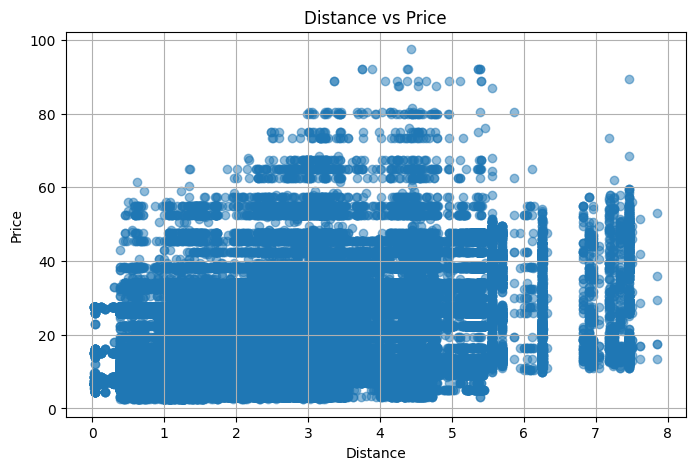

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(rides_df['distance'], rides_df['price'], alpha=0.5)
plt.xlabel('Distance')
plt.ylabel('Price')
plt.title('Distance vs Price')
plt.grid(True)
plt.show()


Checking Null values

In [11]:
rides_df.isna().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [12]:
rides_df=rides_df.dropna(axis=0).reset_index(drop=True)

Cheking Duplicated values


In [13]:
rides_df.duplicated().sum()

np.int64(0)

Cheking null values on weather

In [14]:
weather_df.isnull().sum()

,0
temp,0
location,0
clouds,0
pressure,0
rain,5382
time_stamp,0
humidity,0
wind,0


Replacing rain feature NAN using 0

In [15]:
weather_df=weather_df.fillna(0)

In [16]:
weather_df.isna().sum()

,0
temp,0
location,0
clouds,0
pressure,0
rain,0
time_stamp,0
humidity,0
wind,0


Creating Average weather dataframe

In [17]:
weather_df

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,1545003901,0.75,11.49
...,...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,0.0000,1543819974,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,0.0000,1543819974,0.96,1.54
6273,44.82,South Station,0.89,1000.70,0.0000,1543819974,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,0.0000,1543819974,0.96,1.54


/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


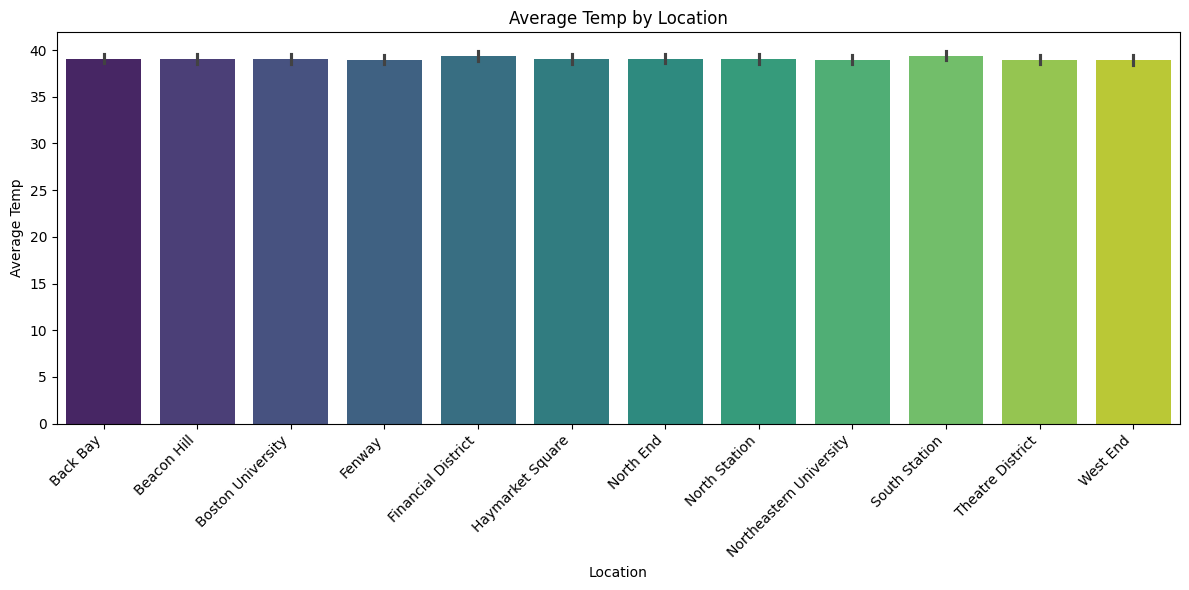

/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


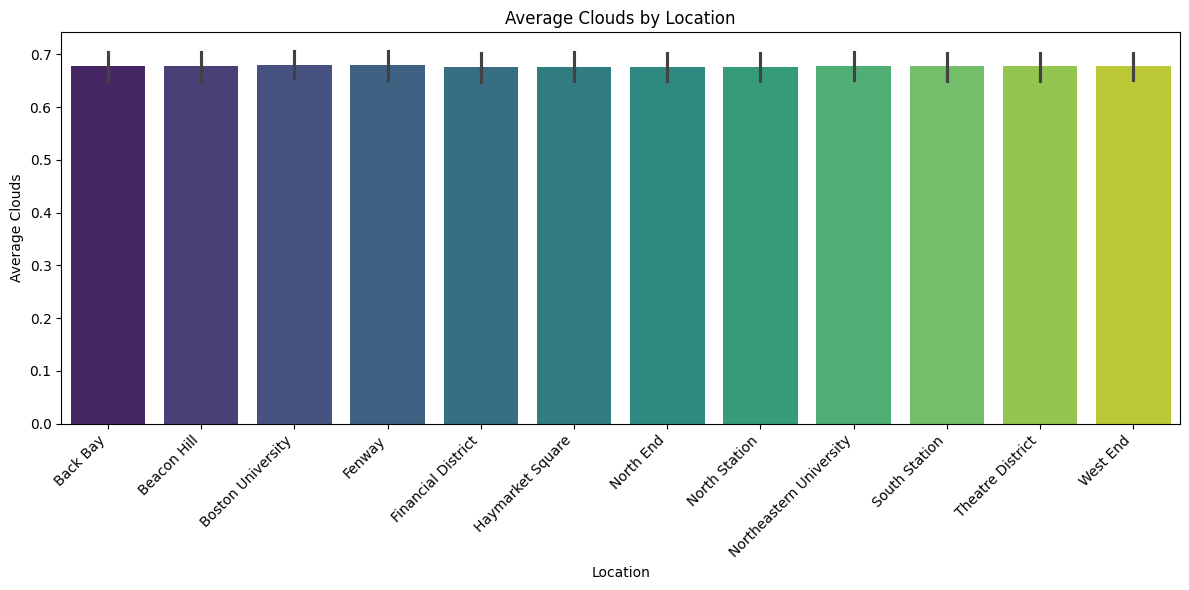

/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


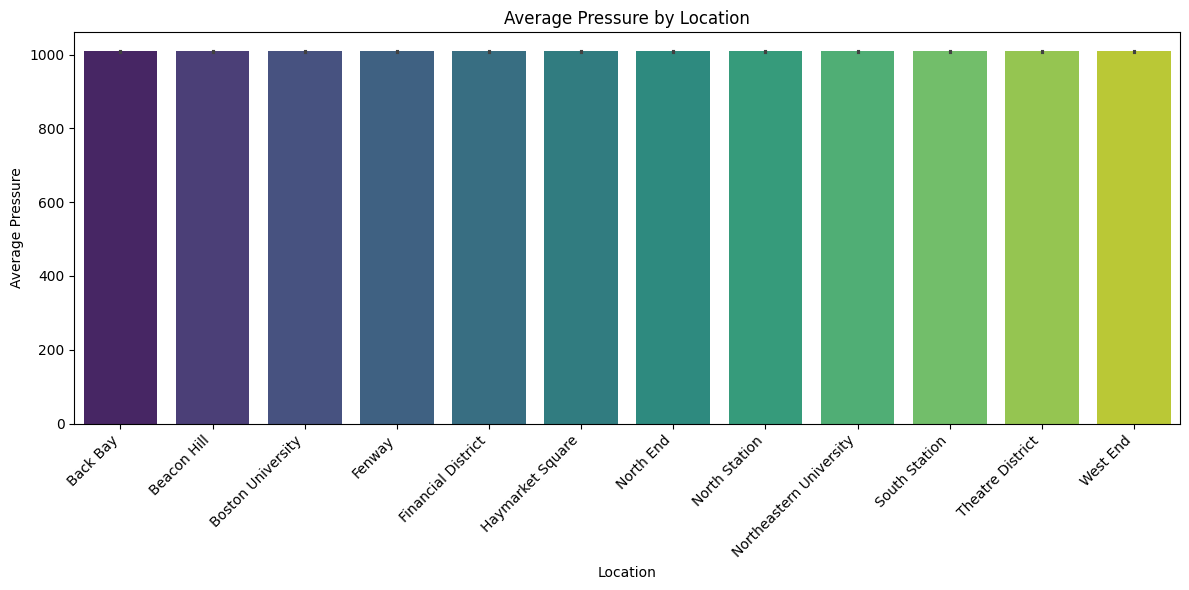

/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


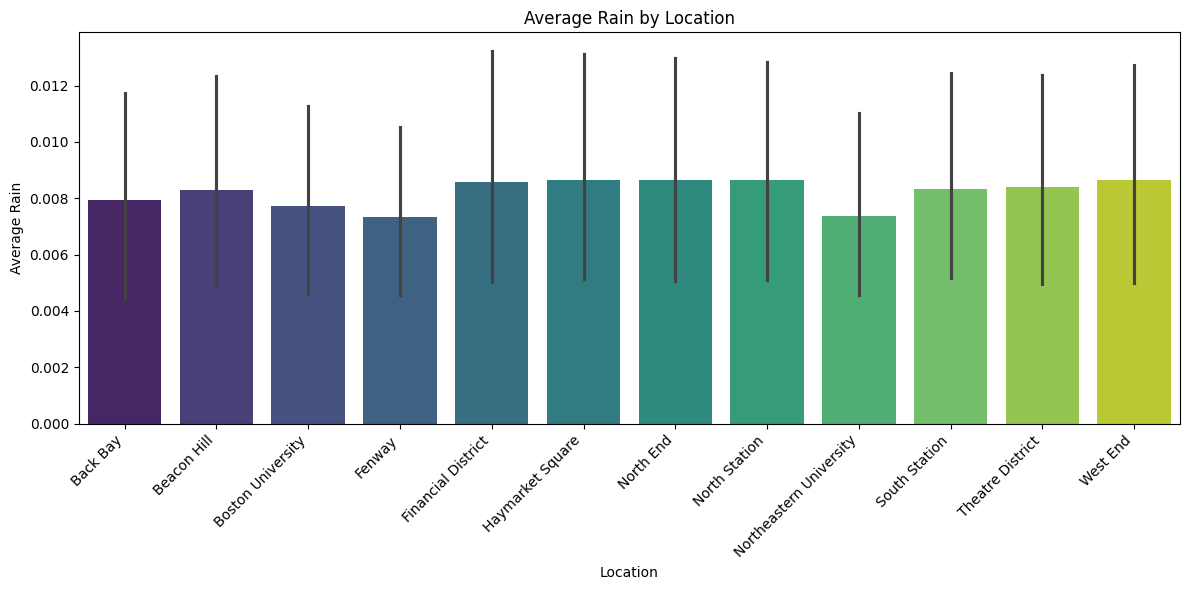

/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


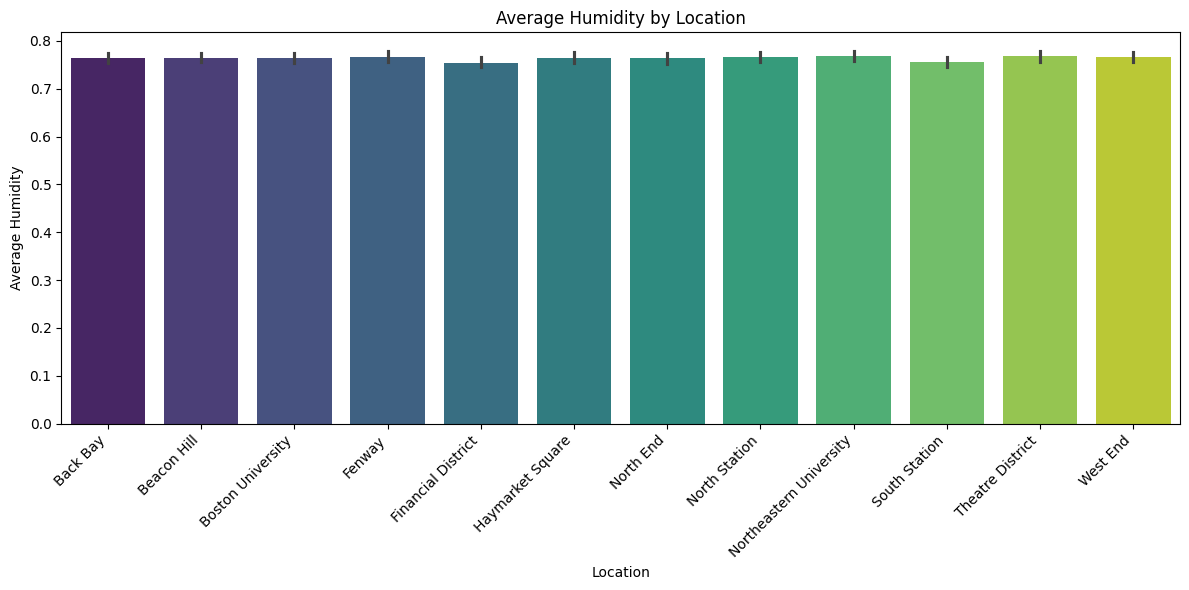

/tmp/ipykernel_1881/2508004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')


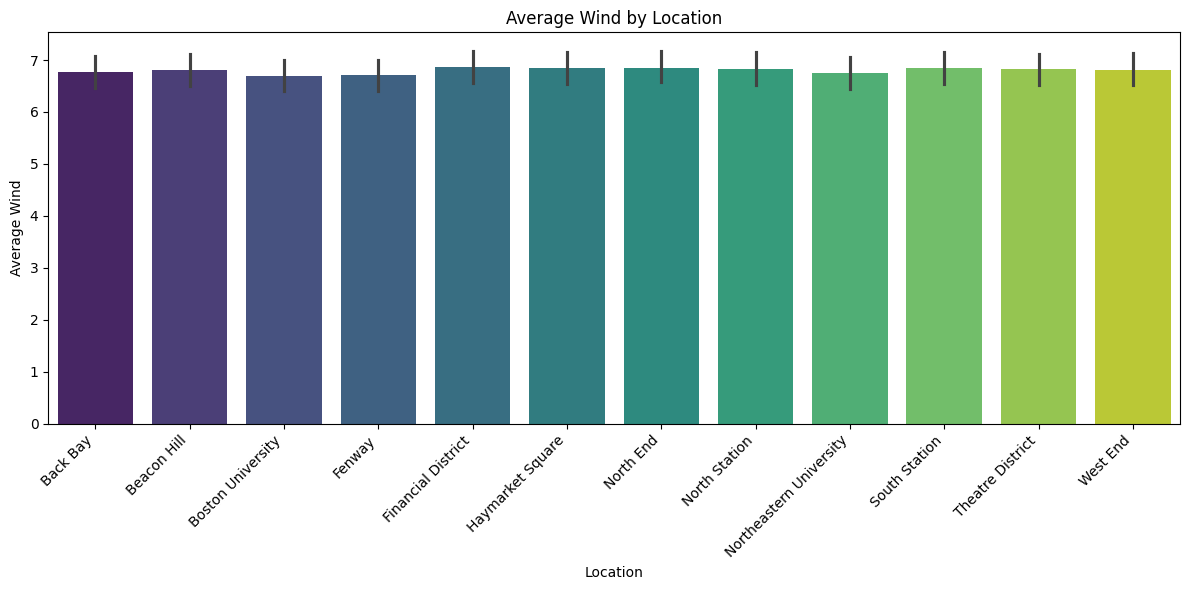

In [18]:

weather_features = ['temp', 'clouds', 'pressure', 'rain', 'humidity', 'wind']

for feature in weather_features:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='location', y=feature, data=weather_df, palette='viridis')
    plt.title(f'Average {feature.replace("_", " ").title()} by Location')
    plt.xlabel('Location')
    plt.ylabel(f'Average {feature.replace("_", " ").title()}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [19]:
weather_df=weather_df.drop('time_stamp', axis=1)
weather_df

,temp,location,clouds,pressure,rain,humidity,wind
0,42.42,Back Bay,1.00,1012.14,0.1228,0.77,11.25
1,42.43,Beacon Hill,1.00,1012.15,0.1846,0.76,11.32
2,42.50,Boston University,1.00,1012.15,0.1089,0.76,11.07
3,42.11,Fenway,1.00,1012.13,0.0969,0.77,11.09
4,43.13,Financial District,1.00,1012.14,0.1786,0.75,11.49
...,...,...,...,...,...,...,...
6271,44.72,North Station,0.89,1000.69,0.0000,0.96,1.52
6272,44.85,Northeastern University,0.88,1000.71,0.0000,0.96,1.54
6273,44.82,South Station,0.89,1000.70,0.0000,0.96,1.54
6274,44.78,Theatre District,0.89,1000.70,0.0000,0.96,1.54


In [20]:
weather_df=weather_df.groupby('location').mean().reset_index(drop=False)

Merge Dataset


In [21]:
source_weather_df=weather_df.rename(
    columns={
        'location' : 'source',
        'temp'   : 'source_temp',
        'clouds' : 'source_clouds',
        'pressure' : 'source_pressure',
        'rain' : 'source_rain',
        'humadity' : 'source_humadity',
        'wind' : 'source_wind'

    }
)

source_weather_df

,source,source_temp,source_clouds,source_pressure,source_rain,humidity,source_wind
0,Back Bay,39.082122,0.678432,1008.447820,0.007925,0.764073,6.778528
1,Beacon Hill,39.047285,0.677801,1008.448356,0.008297,0.765048,6.810325
2,Boston University,39.047744,0.679235,1008.459254,0.007738,0.763786,6.692180
3,Fenway,38.964379,0.679866,1008.453289,0.007343,0.767266,6.711721
4,Financial District,39.410822,0.676730,1008.435793,0.008563,0.754837,6.860019
5,Haymarket Square,39.067897,0.676711,1008.445239,0.008660,0.764837,6.843193
6,North End,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117
7,North Station,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
8,Northeastern University,38.975086,0.678317,1008.444168,0.007358,0.767648,6.749426
9,South Station,39.394092,0.677495,1008.438031,0.008310,0.755468,6.848948


In [22]:
destination_weather_df=weather_df.rename(
    columns={
        'location' : 'destination',
        'temp'   : 'destination_temp',
        'clouds' : 'destination_clouds',
        'pressure' : 'destination_pressure',
        'rain' : 'destination_rain',
        'humidity' : 'destination_humadity',
        'wind' : 'destination_wind'

    }
)

destination_weather_df

,destination,destination_temp,destination_clouds,destination_pressure,destination_rain,destination_humadity,destination_wind
0,Back Bay,39.082122,0.678432,1008.447820,0.007925,0.764073,6.778528
1,Beacon Hill,39.047285,0.677801,1008.448356,0.008297,0.765048,6.810325
2,Boston University,39.047744,0.679235,1008.459254,0.007738,0.763786,6.692180
3,Fenway,38.964379,0.679866,1008.453289,0.007343,0.767266,6.711721
4,Financial District,39.410822,0.676730,1008.435793,0.008563,0.754837,6.860019
5,Haymarket Square,39.067897,0.676711,1008.445239,0.008660,0.764837,6.843193
6,North End,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117
7,North Station,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
8,Northeastern University,38.975086,0.678317,1008.444168,0.007358,0.767648,6.749426
9,South Station,39.394092,0.677495,1008.438031,0.008310,0.755468,6.848948


In [23]:
data_df = (rides_df
           .merge(source_weather_df, on='source')
           .merge(destination_weather_df, on='destination'))

data_df

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,...,source_pressure,source_rain,humidity,source_wind,destination_temp,destination_clouds,destination_pressure,destination_rain,destination_humadity,destination_wind
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,...,1008.445239,0.008660,0.764837,6.843193,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,...,1008.445239,0.008660,0.764837,6.843193,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,...,1008.445239,0.008660,0.764837,6.843193,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,...,1008.445239,0.008660,0.764837,6.843193,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,...,1008.445239,0.008660,0.764837,6.843193,39.035315,0.676998,1008.442811,0.008649,0.765545,6.835755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637971,1.00,Uber,1543708385534,North End,West End,9.5,1.0,353e6566-b272-479e-a9c6-98bd6cb23f25,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,...,1008.441090,0.008657,0.767266,6.816233,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117
637972,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,...,1008.441090,0.008657,0.767266,6.816233,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117
637973,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,...,1008.441090,0.008657,0.767266,6.816233,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117
637974,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV,...,1008.441090,0.008657,0.767266,6.816233,39.090841,0.676730,1008.441912,0.008644,0.764054,6.853117


Preprocessing

Encoding

In [24]:
def onehot_encode(df, column, prefix):
  df=df.copy()
  dummies=pd.get_dummies(df[column], prefix=prefix)
  df=pd.concat([df, dummies], axis=1)
  df=df.drop(column, axis=1)
  return df

In [25]:
def preprocess_inputs(df):
  df=df.copy()
  df=df.drop('id', axis=1)



  df['cab_type']=df['cab_type'].replace({'Lyft' :0, 'Uber' :1})


  for column, prefix in [('destination', 'dest'),('source', 'src'), ('product_id','pid'),('name','nm')]:
    df=onehot_encode(df, column=column, prefix=prefix)



  return df

In [26]:
x=preprocess_inputs(data_df)


/tmp/ipykernel_1881/2045458748.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cab_type']=df['cab_type'].replace({'Lyft' :0, 'Uber' :1})


In [27]:
data_df['cab_type'].unique()

array(['Lyft', 'Uber'], dtype=object)

In [28]:
x.columns

Index(['distance', 'cab_type', 'time_stamp', 'price', 'surge_multiplier',
       'source_temp', 'source_clouds', 'source_pressure', 'source_rain',
       'humidity', 'source_wind', 'destination_temp', 'destination_clouds',
       'destination_pressure', 'destination_rain', 'destination_humadity',
       'destination_wind', 'dest_Back Bay', 'dest_Beacon Hill',
       'dest_Boston University', 'dest_Fenway', 'dest_Financial District',
       'dest_Haymarket Square', 'dest_North End', 'dest_North Station',
       'dest_Northeastern University', 'dest_South Station',
       'dest_Theatre District', 'dest_West End', 'src_Back Bay',
       'src_Beacon Hill', 'src_Boston University', 'src_Fenway',
       'src_Financial District', 'src_Haymarket Square', 'src_North End',
       'src_North Station', 'src_Northeastern University', 'src_South Station',
       'src_Theatre District', 'src_West End',
       'pid_55c66225-fbe7-4fd5-9072-eab1ece5e23e',
       'pid_6c84fd89-3f11-4782-9b50-97c468b19529

In [29]:
x.head()

,distance,cab_type,time_stamp,price,surge_multiplier,source_temp,source_clouds,source_pressure,source_rain,humidity,...,nm_Lux,nm_Lux Black,nm_Lux Black XL,nm_Lyft,nm_Lyft XL,nm_Shared,nm_UberPool,nm_UberX,nm_UberXL,nm_WAV
0,0.44,0,1544952607890,5.0,1.0,39.067897,0.676711,1008.445239,0.00866,0.764837,...,False,False,False,False,False,True,False,False,False,False
1,0.44,0,1543284023677,11.0,1.0,39.067897,0.676711,1008.445239,0.00866,0.764837,...,True,False,False,False,False,False,False,False,False,False
2,0.44,0,1543366822198,7.0,1.0,39.067897,0.676711,1008.445239,0.00866,0.764837,...,False,False,False,True,False,False,False,False,False,False
3,0.44,0,1543553582749,26.0,1.0,39.067897,0.676711,1008.445239,0.00866,0.764837,...,False,False,True,False,False,False,False,False,False,False
4,0.44,0,1543463360223,9.0,1.0,39.067897,0.676711,1008.445239,0.00866,0.764837,...,False,False,False,False,True,False,False,False,False,False


Seperate Terget feature (price) from dataset

In [30]:
X=x.drop('price',axis=1)
Y=x['price']



Train-Test Spliting

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, train_size=0.7, shuffle=True, random_state=1)

Standard Scaling

In [32]:
numeric_features = [
    'distance', 'source_temp', 'source_clouds', 'source_pressure',
    'source_rain', 'humidity', 'source_wind', 'destination_temp',
    'destination_clouds', 'destination_pressure', 'destination_rain',
    'destination_humadity', 'destination_wind', 'surge_multiplier'
]


In [33]:

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[numeric_features]=scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]=scaler.transform(X_test[numeric_features])



Model Train

Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)



LinearRegression()

In [35]:
y_pred=model.predict(X_test)



Evaluate model performance

In [36]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test, y_pred)
print("The r2 value : ",r2)


The r2 value :  0.9285444262717264


In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.4858770504768937


Comparison Between actual vs predicted price

In [38]:
comparison_df = pd.DataFrame({
    'Actual Price': Y_test,
    'Predicted Price': y_pred
})
print(comparison_df.head(10))


        Actual Price  Predicted Price
606015          16.5        14.589046
503810          10.5         9.165807
207240           8.0         7.528780
331602           3.5         1.969968
584694          26.0        25.163509
223741          16.5        16.342620
60038           16.5        15.129247
379924          10.5         8.456768
317992          16.5        16.515341
78272           17.5        17.075002


Cross Validation (R2,RMSE)

In [39]:
from sklearn.model_selection import cross_val_score
r2_score_cv=cross_val_score(model, X, Y , scoring='r2',cv=5)
print("R2 scores from CV:", r2_score_cv)
print("Average R2:", r2_score_cv.mean())

rmse_scores_CV = cross_val_score(model, X, Y, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores_CV = -rmse_scores_CV
print("RMSE values:", rmse_scores_CV)
print("Average RMSE:", rmse.mean())



R2 scores from CV: [0.92838659 0.92934616 0.92778508 0.92912441 0.92833452]
Average R2: 0.9285953516516325
RMSE values: [2.50662803 2.47477589 2.51325831 2.47352107 2.48975533]
Average RMSE: 2.4858770504768937


Random Forest Regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)



RandomForestRegressor(random_state=42)

In [41]:
rf_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))
r2 = r2_score(Y_test, rf_pred)

print(f"RMSE: {rmse}")
print(f"R^2 Score: {r2}")

RMSE: 1.8139022919883563
R^2 Score: 0.9619543857888797


In [42]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Actual Price": Y_test,
    "Predicted Price": rf_pred
})

print(comparison_df.head(10))


        Actual Price  Predicted Price
606015          16.5         16.26000
503810          10.5         10.23000
207240           8.0          8.12581
331602           3.5          4.33500
584694          26.0         26.42000
223741          16.5         16.56000
60038           16.5         16.50000
379924          10.5         12.23500
317992          16.5         16.50000
78272           17.5         17.23500


XGboost

In [43]:
import xgboost as xgb
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
xgb_pred = model.predict(X_test)


rmse = np.sqrt(mean_squared_error(Y_test, xgb_pred))
r2 = r2_score(Y_test, xgb_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1.661781871560552
R2 Score: 0.9680680930915642


In [45]:
compare = pd.DataFrame({
    "Actual": Y_test.values[:20],
    "RandomForest_Pred": rf_pred[:20],
    "XGBoost_Pred": xgb_pred[:20],
})
print("\n=== Sample Predictions Comparison ===")
print(compare)


=== Sample Predictions Comparison ===
    Actual  RandomForest_Pred  XGBoost_Pred
0     16.5          16.260000     15.288861
1     10.5          10.230000     10.199663
2      8.0           8.125810      8.188194
3      3.5           4.335000      4.079803
4     26.0          26.420000     26.710964
5     16.5          16.560000     16.620562
6     16.5          16.500000     15.635213
7     10.5          12.235000      9.534331
8     16.5          16.500000     16.487474
9     17.5          17.235000     17.105831
10     8.0           9.885000      9.813857
11    19.5          16.560000     16.840761
12    17.0          15.865000     15.884574
13     9.5          10.010000      9.767987
14    13.5          13.920000     14.124089
15    13.5          14.130000     15.449758
16    18.0          21.637500     17.630005
17    34.0          34.334167     34.225636
18    23.5          21.520000     22.315178
19     9.0           9.570000      8.837893
